# Аналитика продаж магазина электроники

Этот notebook показывает полный учебный аналитический цикл на синтетическом наборе из **10 000 строк и 18 столбцов**. Одна строка описывает одну товарную позицию внутри заказа. Материал рассчитан на начинающих аналитиков: ключевые термины поясняются, а код снабжён русскими комментариями.

Логика работы: **бизнес-вопрос → загрузка и осмотр → качество данных → очистка/ETL → preprocessing → EDA → KPI → статистика → ABC-XYZ → RFM → подготовка данных для Yandex DataLens → выводы и ограничения**.

## 1. Цель анализа

Цель — понять структуру продаж учебного магазина электроники: динамику выручки и прибыли, вклад категорий/брендов/каналов, возвраты, скидки, товарный портфель и клиентские сегменты.

Результат предназначен для учебного руководителя розничной сети и служит примером того, как из «грязного» файла получить проверенные аналитические таблицы и BI-витрины.

## 2. Аналитические вопросы и гипотезы

Основные вопросы:

1. Как меняются выручка, прибыль и число заказов по месяцам?
2. Какие категории, бренды, города и каналы формируют основной результат?
3. Где выше скидки и возвраты?
4. Какие товары относятся к ABC-XYZ классам?
5. Какие клиентские сегменты выделяются по RFM?
6. Какие наблюдаемые различия подтверждаются статистическими тестами?

Рабочие гипотезы:

- **H1:** в онлайн-каналах скидка в среднем/по распределению выше, чем в офлайн-магазине;
- **H2:** доля возвратов различается между товарными категориями;
- **H3:** между размером скидки и количеством единиц в строке есть положительная монотонная связь.

Гипотеза — проверяемое предположение. Даже статистически значимый результат не доказывает причинность.

## 3. Данные, единица наблюдения и ожидаемый результат

Источник — синтетический CSV `data/raw/electronics_sales_10000.csv`.

**Grain / единица наблюдения:** одна товарная позиция внутри заказа. Поэтому `line_id` должен быть уникальным после удаления полных дублей, а `order_id` может повторяться.

Ожидаемый результат:

- очищенный line-level CSV;
- производные показатели выручки, прибыли и маржи;
- EDA и статистические проверки;
- ABC-XYZ по товарам;
- RFM по клиентам;
- отдельные CSV-витрины для Yandex DataLens;
- итоговые выводы, ограничения и рекомендации.

## 4. Подготовка окружения

`pandas` используется для таблиц, `NumPy` — для числовых расчётов, `matplotlib` — для графиков, `SciPy` — для статистических тестов. Пути задаются относительно корня проекта, чтобы notebook не зависел от компьютера автора.

In [1]:
# Импортируем Path для кроссплатформенной работы с путями.
from pathlib import Path
# Импортируем warnings для управления некритичными предупреждениями.
import warnings
# Импортируем NumPy для числовых расчётов.
import numpy as np
# Импортируем pandas для работы с табличными данными.
import pandas as pd
# Импортируем matplotlib для построения графиков.
import matplotlib.pyplot as plt
# Импортируем статистические тесты из SciPy.
from scipy.stats import mannwhitneyu, chi2_contingency, spearmanr
# Импортируем display и Markdown для аккуратного вывода в notebook.
from IPython.display import display, Markdown

# Скрываем только FutureWarning, чтобы учебный вывод оставался читаемым.
warnings.filterwarnings('ignore', category=FutureWarning)
# Настраиваем читаемый стиль графиков.
plt.rcParams['axes.grid'] = True
# Устанавливаем шрифт с поддержкой кириллицы.
plt.rcParams['font.family'] = 'DejaVu Sans'
# Задаём размер графика по умолчанию.
plt.rcParams['figure.figsize'] = (11, 6)
# Показываем до 30 столбцов в DataFrame.
pd.set_option('display.max_columns', 30)
# Форматируем числа до двух знаков после запятой.
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

# Определяем корень проекта как текущую рабочую папку.
PROJECT_DIR = Path('.')
# Формируем путь к исходным данным.
RAW_PATH = PROJECT_DIR / 'data' / 'raw' / 'electronics_sales_10000.csv'
# Формируем путь к очищенным данным.
CLEAN_PATH = PROJECT_DIR / 'data' / 'processed' / 'electronics_sales_clean.csv'
# Формируем каталог BI-витрин.
DATALENS_DIR = PROJECT_DIR / 'data' / 'datalens'
# Формируем каталог для сохранения графиков.
CHART_DIR = PROJECT_DIR / 'outputs' / 'charts'
# Создаём каталоги, если они ещё не существуют.
DATALENS_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

## 5. Загрузка данных

`pd.read_csv()` читает CSV в `DataFrame`. Сразу проверяем, что файл существует и содержит ожидаемые **10 000 строк**.

In [2]:
# Проверяем наличие исходного файла.
assert RAW_PATH.exists(), f'Файл не найден: {RAW_PATH.resolve()}'
# Загружаем исходный CSV с BOM-совместимой UTF-8 кодировкой.
raw_df = pd.read_csv(RAW_PATH, encoding='utf-8-sig')
# Печатаем размер исходной таблицы.
print(f'Размер исходного датасета: {raw_df.shape[0]:,} строк и {raw_df.shape[1]} столбцов.')
# Контролируем ограничение учебного задания.
assert raw_df.shape[0] == 10000, 'Исходный датасет должен содержать ровно 10 000 строк.'
# Показываем первые пять строк.
display(raw_df.head())

Размер исходного датасета: 10,000 строк и 18 столбцов.


,line_id,order_id,sale_date,customer_id,city,sales_channel,customer_segment,payment_method,product_id,product_name,category,brand,promo_campaign,discount_pct,quantity,unit_price_rub,unit_cost_rub,returned
0,L000001,ORD001544,2025-08-20,C01091,Санкт-Петербург,Сайт,Новый,СБП,P044,Аудио Marshall Model 44,Аудио,Marshall,Back-to-school,0.15,2,"40,727.77","34,013.16",0
1,L000002,ORD000204,2025-07-04,C01701,Екатеринбург,Магазин,Регулярный,Карта,P005,Смартфоны realme Model 05,Смартфоны,realme,Без акции,0.04,2,"47,737.10","30,814.55",1
2,L000003,ORD001458,2025-06-19,C00619,Москва,Магазин,Новый,Наличные,P052,Аксессуары Baseus Model 52,Аксессуары,Baseus,Без акции,0.05,1,"4,619.43","3,334.68",0
3,L000004,ORD000154,2025-07-04,C00948,Самара,Магазин,Регулярный,Карта,P012,Ноутбуки Lenovo Model 12,Ноутбуки,Lenovo,Без акции,0.03,2,"175,503.36","138,234.66",0
4,L000005,ORD002194,2025-04-04,C00264,Казань,Магазин,Регулярный,Карта,P059,Игровая техника HyperX Model 59,Игровая техника,HyperX,Без акции,0.02,1,"31,879.41","20,907.66",0


## 6. Словарь полей

Ключевой момент: `line_id` идентифицирует строку продажи, а `order_id` — заказ. Один заказ может содержать несколько товаров, поэтому для количества заказов нельзя использовать обычное число строк.

In [3]:
# Создаём компактный словарь полей прямо в notebook.
data_dictionary = pd.DataFrame({
    'field': ['line_id','order_id','sale_date','customer_id','customer_segment','city','sales_channel','category','brand','product_id','product_name','quantity','unit_price_rub','discount_pct','unit_cost_rub','payment_method','promo_campaign','returned'],
    'meaning': ['ID строки','ID заказа','Дата продажи','ID клиента','Исходный сегмент','Город','Канал продаж','Категория','Бренд','ID товара','Название товара','Количество','Цена за единицу','Доля скидки','Себестоимость единицы','Способ оплаты','Акция','Возврат 1/0']
})
# Выводим словарь.
display(data_dictionary)

,field,meaning
0,line_id,ID строки
1,order_id,ID заказа
2,sale_date,Дата продажи
3,customer_id,ID клиента
4,customer_segment,Исходный сегмент
5,city,Город
6,sales_channel,Канал продаж
7,category,Категория
8,brand,Бренд
9,product_id,ID товара


## 7. Первичный осмотр данных

Проверяем типы, пропуски, описательную статистику и число уникальных значений. На этом этапе ничего не исправляем: сначала фиксируем симптомы качества.

In [4]:
# Показываем техническую информацию о таблице.
raw_df.info()
# Выводим описательную статистику числовых полей.
display(raw_df.describe(include='number').T)
# Считаем уникальные значения по каждому столбцу.
display(raw_df.nunique(dropna=False).to_frame('unique_values'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   line_id           10000 non-null  object 
 1   order_id          10000 non-null  object 
 2   sale_date         10000 non-null  object 
 3   customer_id       10000 non-null  object 
 4   city              10000 non-null  object 
 5   sales_channel     10000 non-null  object 
 6   customer_segment  9960 non-null   object 
 7   payment_method    9980 non-null   object 
 8   product_id        10000 non-null  object 
 9   product_name      10000 non-null  object 
 10  category          10000 non-null  object 
 11  brand             10000 non-null  object 
 12  promo_campaign    10000 non-null  object 
 13  discount_pct      9965 non-null   float64
 14  quantity          10000 non-null  int64  
 15  unit_price_rub    10000 non-null  float64
 16  unit_cost_rub     9970 non-null   float64

,count,mean,std,min,25%,50%,75%,max
discount_pct,"9,965.00",0.07,0.06,-0.20,0.03,0.06,0.09,0.95
quantity,"10,000.00",1.27,1.63,-2.00,1.00,1.00,1.00,50.00
unit_price_rub,"10,000.00","50,681.18","55,697.23",-100.00,"11,092.86","35,394.99","75,384.29","999,999.00"
unit_cost_rub,"9,970.00","36,445.43","45,541.07",-50.00,"7,387.49","24,632.17","51,428.25","999,999.00"
returned,"10,000.00",0.07,0.26,0.00,0.00,0.00,0.00,1.00


,unique_values
line_id,9975
order_id,6000
sale_date,365
customer_id,1814
city,18
sales_channel,9
customer_segment,4
payment_method,13
product_id,60
product_name,60


## 8. Проверка типов и преобразование даты

Дата в исходном файле намеренно записана в нескольких текстовых форматах. `format='mixed'` позволяет разобрать смешанные представления, а `errors='coerce'` делает нераспознанные даты явными пропусками.

In [5]:
# Создаём рабочую копию, чтобы не изменять raw_df.
df = raw_df.copy()
# Нормализуем названия столбцов.
df.columns = df.columns.str.strip().str.lower()
# Преобразуем смешанные форматы даты.
df['sale_date'] = pd.to_datetime(df['sale_date'], format='mixed', dayfirst=True, errors='coerce')
# Считаем нераспознанные даты.
invalid_dates = int(df['sale_date'].isna().sum())
# Печатаем результат.
print(f'Нераспознанных дат: {invalid_dates}')
# Проверяем диапазон дат после преобразования.
print('Период:', df['sale_date'].min(), '—', df['sale_date'].max())

Нераспознанных дат: 0
Период: 2025-01-01 00:00:00 — 2025-12-31 00:00:00


## 9. Пропущенные значения

Пропуск не равен нулю. Сначала измеряем количество и долю пропусков, затем применяем разные правила в зависимости от смысла поля.

In [6]:
# Считаем количество пропусков.
missing_count = df.isna().sum()
# Считаем долю пропусков в процентах.
missing_pct = df.isna().mean().mul(100)
# Собираем только столбцы с пропусками.
missing_report = pd.DataFrame({'missing_count': missing_count, 'missing_share_pct': missing_pct})
# Выводим проблемные поля.
display(missing_report[missing_report['missing_count'] > 0].sort_values('missing_count', ascending=False))

,missing_count,missing_share_pct
customer_segment,40,0.40
discount_pct,35,0.35
unit_cost_rub,30,0.30
payment_method,20,0.20


## 10. Дубликаты и уникальность идентификаторов

Полный дубль завышает строковые суммы. Проверяем и полные дубликаты, и повторяемость `line_id`. Повторяющийся `order_id` является нормой, потому что один заказ может включать несколько товарных позиций.

In [7]:
# Считаем полные дубликаты строк.
full_duplicates = int(df.duplicated().sum())
# Считаем уникальные line_id.
unique_lines_before = int(df['line_id'].nunique())
# Считаем уникальные order_id.
unique_orders_before = int(df['order_id'].nunique())
# Печатаем контрольные значения.
print('Полных дублей:', full_duplicates)
print('Уникальных line_id:', unique_lines_before)
print('Уникальных order_id:', unique_orders_before)

Полных дублей: 25
Уникальных line_id: 9975
Уникальных order_id: 6000


## 11. Согласованность категориальных значений

Пробелы и регистр могут искусственно создать отдельные категории. Нормализуем строки через `strip()` и `casefold()`, затем возвращаем утверждённые русские названия.

In [8]:
# Задаём эталонные категории для нормализации.
reference_values = {
    'sales_channel': ['Магазин','Сайт','Маркетплейс'],
    'category': ['Смартфоны','Ноутбуки','Телевизоры','Бытовая техника','Аудио','Аксессуары','Игровая техника'],
    'city': ['Москва','Санкт-Петербург','Казань','Екатеринбург','Новосибирск','Самара'],
    'payment_method': ['Карта','СБП','Наличные','Рассрочка'],
}
# Проходим по каждому категориальному полю.
for column, reference in reference_values.items():
    # Строим словарь casefold-значение -> эталонное написание.
    mapping = {value.casefold(): value for value in reference}
    # Убираем внешние пробелы, приводим к casefold и заменяем на эталон.
    normalized = df[column].astype('string').str.strip().str.casefold().map(mapping)
    # Сохраняем нормализованный столбец, не превращая исходные пропуски в текст.
    df[column] = normalized
# Показываем уникальные значения после нормализации.
for column in reference_values:
    print(column, sorted(df[column].dropna().unique().tolist()))

sales_channel ['Магазин', 'Маркетплейс', 'Сайт']
category ['Аксессуары', 'Аудио', 'Бытовая техника', 'Игровая техника', 'Ноутбуки', 'Смартфоны', 'Телевизоры']
city ['Екатеринбург', 'Казань', 'Москва', 'Новосибирск', 'Самара', 'Санкт-Петербург']
payment_method ['Карта', 'Наличные', 'Рассрочка', 'СБП']


## 12. Числовые правила и поиск аномалий

Для учебного примера задаём проверяемые диапазоны:

- `quantity`: 1–10;
- `unit_price_rub`: 300–500 000 руб.;
- `discount_pct`: 0–0,60;
- `unit_cost_rub`: 100–400 000 руб.

Это **правила конкретного синтетического кейса**, а не универсальные границы для реального ритейла.

In [9]:
# Перечисляем числовые поля, которые должны быть числами.
numeric_columns = ['quantity','unit_price_rub','discount_pct','unit_cost_rub','returned']
# Принудительно переводим их в числовой формат.
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')
# Строим маски некорректных значений.
invalid_quantity = ~df['quantity'].between(1, 10) | df['quantity'].isna()
invalid_price = ~df['unit_price_rub'].between(300, 500000) | df['unit_price_rub'].isna()
invalid_discount = ~df['discount_pct'].between(0, 0.60) | df['discount_pct'].isna()
invalid_cost = ~df['unit_cost_rub'].between(100, 400000) | df['unit_cost_rub'].isna()
# Выводим количество проблем.
print('Некорректное количество:', int(invalid_quantity.sum()))
print('Некорректная цена:', int(invalid_price.sum()))
print('Некорректная скидка:', int(invalid_discount.sum()))
print('Некорректная себестоимость:', int(invalid_cost.sum()))

Некорректное количество: 30
Некорректная цена: 18
Некорректная скидка: 59
Некорректная себестоимость: 50


## 13. Очистка данных (ETL)

Удаляем полные дубликаты, восстанавливаем пропуски и аномалии устойчивыми правилами. Для цен/себестоимости используем медиану по товару, для скидки — медиану по каналу и категории, для количества — медиану по категории. Категориальные пропуски восстанавливаем из устойчивого контекста.

In [10]:
# Удаляем полные дубликаты и сбрасываем индекс.
df = df.drop_duplicates().reset_index(drop=True)
# Заполняем customer_segment наиболее частым значением для конкретного клиента.
segment_by_customer = df.groupby('customer_id')['customer_segment'].agg(lambda s: s.mode().iloc[0] if not s.mode().empty else pd.NA)
df['customer_segment'] = df['customer_segment'].fillna(df['customer_id'].map(segment_by_customer)).fillna('Регулярный')
# Заполняем payment_method модой внутри канала продаж.
payment_by_channel = df.groupby('sales_channel')['payment_method'].agg(lambda s: s.mode().iloc[0] if not s.mode().empty else 'Карта')
df['payment_method'] = df['payment_method'].fillna(df['sales_channel'].map(payment_by_channel)).fillna('Карта')
# Для количества отмечаем невалидные значения как NaN.
df.loc[~df['quantity'].between(1, 10), 'quantity'] = np.nan
# Рассчитываем медиану количества по категории.
qty_median = df.groupby('category')['quantity'].transform('median')
# Заполняем и округляем количество до целого.
df['quantity'] = df['quantity'].fillna(qty_median).round().astype(int)
# Для цены отмечаем невалидные значения как NaN.
df.loc[~df['unit_price_rub'].between(300, 500000), 'unit_price_rub'] = np.nan
# Заполняем цену медианой по product_id.
price_median = df.groupby('product_id')['unit_price_rub'].transform('median')
df['unit_price_rub'] = df['unit_price_rub'].fillna(price_median)
# Для скидки отмечаем значения вне диапазона как NaN.
df.loc[~df['discount_pct'].between(0, 0.60), 'discount_pct'] = np.nan
# Рассчитываем медиану скидки по каналу и категории.
discount_median = df.groupby(['sales_channel','category'])['discount_pct'].transform('median')
# Заполняем скидку групповой медианой, затем общей медианой как fallback.
df['discount_pct'] = df['discount_pct'].fillna(discount_median).fillna(df['discount_pct'].median())
# Для себестоимости отмечаем невалидные значения как NaN.
df.loc[~df['unit_cost_rub'].between(100, 400000), 'unit_cost_rub'] = np.nan
# Заполняем себестоимость медианой по товару.
cost_median = df.groupby('product_id')['unit_cost_rub'].transform('median')
df['unit_cost_rub'] = df['unit_cost_rub'].fillna(cost_median)
# Приводим returned к целому типу.
df['returned'] = df['returned'].astype(int)
# Округляем денежные поля и скидку.
df['unit_price_rub'] = df['unit_price_rub'].round(2)
df['unit_cost_rub'] = df['unit_cost_rub'].round(2)
df['discount_pct'] = df['discount_pct'].round(4)
# Печатаем размер после удаления дублей.
print(f'После очистки: {df.shape[0]:,} строк.')

После очистки: 9,975 строк.


## 14. Контроль качества после очистки

Очистка завершена только после повторной проверки. `assert` делает требования исполняемыми: при нарушении notebook остановится до аналитических выводов.

In [11]:
# Определяем критические поля.
critical = ['line_id','order_id','sale_date','customer_id','city','sales_channel','category','brand','product_id','product_name','quantity','unit_price_rub','discount_pct','unit_cost_rub','payment_method','promo_campaign','returned']
# Проверяем отсутствие критических пропусков.
assert df[critical].isna().sum().sum() == 0, 'Остались критические пропуски.'
# Проверяем уникальность строки продажи.
assert df['line_id'].is_unique, 'line_id должен быть уникальным.'
# Проверяем отсутствие полных дублей.
assert df.duplicated().sum() == 0, 'После очистки остались полные дубли.'
# Проверяем дату.
assert df['sale_date'].notna().all(), 'Остались нераспознанные даты.'
# Проверяем диапазоны.
assert df['quantity'].between(1,10).all(), 'Некорректное количество.'
assert df['unit_price_rub'].between(300,500000).all(), 'Некорректная цена.'
assert df['discount_pct'].between(0,0.60).all(), 'Некорректная скидка.'
assert df['unit_cost_rub'].between(100,400000).all(), 'Некорректная себестоимость.'
assert df['returned'].isin([0,1]).all(), 'returned должен быть 0/1.'
# Печатаем итоговый контроль.
print('QA очистки пройден.')
print(f'Очищенная таблица: {df.shape[0]:,} строк; уникальных заказов: {df.order_id.nunique():,}.')

QA очистки пройден.
Очищенная таблица: 9,975 строк; уникальных заказов: 6,000.


## 15. Preprocessing и производные признаки

Создаём признаки, необходимые для анализа и BI. Возврат в этом учебном кейсе упрощённо обнуляет выручку и себестоимость строки; это модельное допущение, а не бухгалтерское правило.

In [12]:
# Создаём копию для аналитических признаков.
analysis_df = df.copy()
# Рассчитываем сумму до скидки.
analysis_df['gross_revenue_rub'] = analysis_df['quantity'] * analysis_df['unit_price_rub']
# Рассчитываем денежный размер скидки.
analysis_df['discount_amount_rub'] = analysis_df['gross_revenue_rub'] * analysis_df['discount_pct']
# Рассчитываем продажу после скидки до учёта возврата.
analysis_df['sales_after_discount_rub'] = analysis_df['gross_revenue_rub'] - analysis_df['discount_amount_rub']
# В учебной модели возвращённая строка не приносит чистой выручки.
analysis_df['net_revenue_rub'] = analysis_df['sales_after_discount_rub'] * (1 - analysis_df['returned'])
# В учебной модели себестоимость возвращённой строки также исключается из реализованной себестоимости.
analysis_df['cost_total_rub'] = analysis_df['quantity'] * analysis_df['unit_cost_rub'] * (1 - analysis_df['returned'])
# Рассчитываем валовую прибыль.
analysis_df['gross_profit_rub'] = analysis_df['net_revenue_rub'] - analysis_df['cost_total_rub']
# Рассчитываем маржинальность только там, где выручка положительна.
analysis_df['margin_pct'] = np.where(analysis_df['net_revenue_rub'] > 0, analysis_df['gross_profit_rub'] / analysis_df['net_revenue_rub'], np.nan)
# Добавляем календарный месяц для временного анализа.
analysis_df['month_start'] = analysis_df['sale_date'].dt.to_period('M').dt.to_timestamp()
# Добавляем номер месяца.
analysis_df['month_num'] = analysis_df['sale_date'].dt.month
# Добавляем год.
analysis_df['year'] = analysis_df['sale_date'].dt.year
# Округляем денежные производные поля.
for column in ['gross_revenue_rub','discount_amount_rub','sales_after_discount_rub','net_revenue_rub','cost_total_rub','gross_profit_rub']:
    analysis_df[column] = analysis_df[column].round(2)
# Сохраняем очищенную line-level таблицу с производными признаками.
analysis_df.to_csv(CLEAN_PATH, index=False, encoding='utf-8-sig')
# Показываем несколько строк.
display(analysis_df.head())

,line_id,order_id,sale_date,customer_id,city,sales_channel,customer_segment,payment_method,product_id,product_name,category,brand,promo_campaign,discount_pct,quantity,unit_price_rub,unit_cost_rub,returned,gross_revenue_rub,discount_amount_rub,sales_after_discount_rub,net_revenue_rub,cost_total_rub,gross_profit_rub,margin_pct,month_start,month_num,year
0,L000001,ORD001544,2025-08-20,C01091,Санкт-Петербург,Сайт,Новый,СБП,P044,Аудио Marshall Model 44,Аудио,Marshall,Back-to-school,0.15,2,"40,727.77","34,013.16",0,"81,455.54","12,169.46","69,286.08","69,286.08","68,026.32","1,259.76",0.02,2025-08-01,8,2025
1,L000002,ORD000204,2025-07-04,C01701,Екатеринбург,Магазин,Регулярный,Карта,P005,Смартфоны realme Model 05,Смартфоны,realme,Без акции,0.04,2,"47,737.10","30,814.55",1,"95,474.20","3,427.52","92,046.68",0.00,0.00,0.00,NaN,2025-07-01,7,2025
2,L000003,ORD001458,2025-06-19,C00619,Москва,Магазин,Новый,Наличные,P052,Аксессуары Baseus Model 52,Аксессуары,Baseus,Без акции,0.05,1,"4,619.43","3,334.68",0,"4,619.43",219.42,"4,400.01","4,400.01","3,334.68","1,065.33",0.24,2025-06-01,6,2025
3,L000004,ORD000154,2025-07-04,C00948,Самара,Магазин,Регулярный,Карта,P012,Ноутбуки Lenovo Model 12,Ноутбуки,Lenovo,Без акции,0.03,2,"175,503.36","138,234.66",0,"351,006.72","9,757.99","341,248.73","341,248.73","276,469.32","64,779.41",0.19,2025-07-01,7,2025
4,L000005,ORD002194,2025-04-04,C00264,Казань,Магазин,Регулярный,Карта,P059,Игровая техника HyperX Model 59,Игровая техника,HyperX,Без акции,0.02,1,"31,879.41","20,907.66",0,"31,879.41",618.46,"31,260.95","31,260.95","20,907.66","10,353.29",0.33,2025-04-01,4,2025


## 16. Общие KPI продаж

Считаем показатели на правильной гранулярности. Количество заказов — это `nunique(order_id)`, а средний чек — общая чистая выручка / число уникальных заказов.

In [13]:
# Считаем общую чистую выручку.
total_revenue = float(analysis_df['net_revenue_rub'].sum())
# Считаем валовую прибыль.
total_profit = float(analysis_df['gross_profit_rub'].sum())
# Считаем число уникальных заказов.
total_orders = int(analysis_df['order_id'].nunique())
# Считаем количество реализованных единиц с исключением возвратов из итогового количества.
units_sold = int((analysis_df['quantity'] * (1 - analysis_df['returned'])).sum())
# Рассчитываем средний чек.
avg_order_value = total_revenue / total_orders
# Рассчитываем общую маржинальность.
overall_margin = total_profit / total_revenue
# Рассчитываем долю возвратов по строкам.
return_rate = float(analysis_df['returned'].mean())
# Рассчитываем среднюю скидку.
avg_discount = float(analysis_df['discount_pct'].mean())
# Собираем KPI в таблицу.
kpi_table = pd.DataFrame({
    'metric': ['Чистая выручка, руб.','Валовая прибыль, руб.','Заказы','Проданные единицы','Средний чек, руб.','Маржинальность','Доля возвратов','Средняя скидка'],
    'value': [total_revenue,total_profit,total_orders,units_sold,avg_order_value,overall_margin,return_rate,avg_discount]
})
# Выводим KPI.
display(kpi_table)

,metric,value
0,"Чистая выручка, руб.","510,820,817.25"
1,"Валовая прибыль, руб.","119,397,206.35"
2,Заказы,"6,000.00"
3,Проданные единицы,"11,380.00"
4,"Средний чек, руб.","85,136.80"
5,Маржинальность,0.23
6,Доля возвратов,0.07
7,Средняя скидка,0.07


## 17. Распределения и выбросы после очистки

После очистки выбросы могут оставаться как реальные редкие значения. Поэтому визуально проверяем распределения цены, выручки строки и скидки, не удаляя значения автоматически только из-за их редкости.

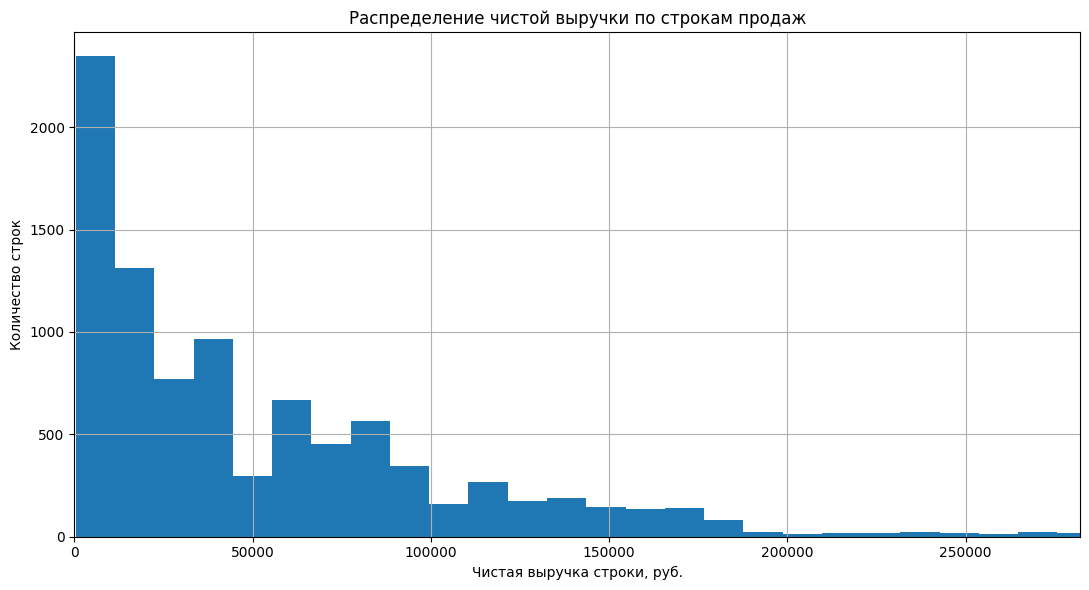

In [14]:
# Создаём фигуру для распределения чистой выручки строки.
plt.figure(figsize=(11,6))
# Строим гистограмму без возвращённых строк.
plt.hist(analysis_df.loc[analysis_df['net_revenue_rub'] > 0, 'net_revenue_rub'], bins=50)
# Добавляем заголовок.
plt.title('Распределение чистой выручки по строкам продаж')
# Подписываем ось X.
plt.xlabel('Чистая выручка строки, руб.')
# Подписываем ось Y.
plt.ylabel('Количество строк')
# Ограничиваем X 99-м перцентилем для читаемости без удаления данных.
plt.xlim(0, analysis_df['net_revenue_rub'].quantile(0.99))
# Уплотняем компоновку.
plt.tight_layout()
# Сохраняем график.
plt.savefig(CHART_DIR / '01_revenue_distribution.png', dpi=150)
# Показываем график.
plt.show()

## 18. Временная динамика

Агрегируем данные по месяцам: выручка, прибыль, уникальные заказы и возвраты. Для полного года это удобный базовый уровень анализа сезонности.

,month_start,net_revenue_rub,gross_profit_rub,orders,units,return_rate,avg_order_value_rub
0,2025-01-01,"34,414,123.77","8,835,835.62",385,765,0.07,"89,387.33"
1,2025-02-01,"29,958,086.13","7,359,785.84",345,676,0.06,"86,835.03"
2,2025-03-01,"38,611,193.29","9,736,129.70",468,913,0.08,"82,502.55"
3,2025-04-01,"34,294,990.25","8,642,583.35",428,845,0.07,"80,128.48"
4,2025-05-01,"44,538,496.42","11,189,666.07",504,1008,0.07,"88,370.03"
5,2025-06-01,"39,294,677.53","9,656,014.80",469,939,0.07,"83,783.96"
6,2025-07-01,"39,425,251.77","9,783,717.73",467,928,0.08,"84,422.38"
7,2025-08-01,"41,171,661.82","9,535,786.57",500,1095,0.08,"82,343.32"
8,2025-09-01,"41,084,430.63","8,913,295.56",541,1090,0.07,"75,941.65"
9,2025-10-01,"49,742,703.96","12,198,760.85",540,1112,0.07,"92,116.12"


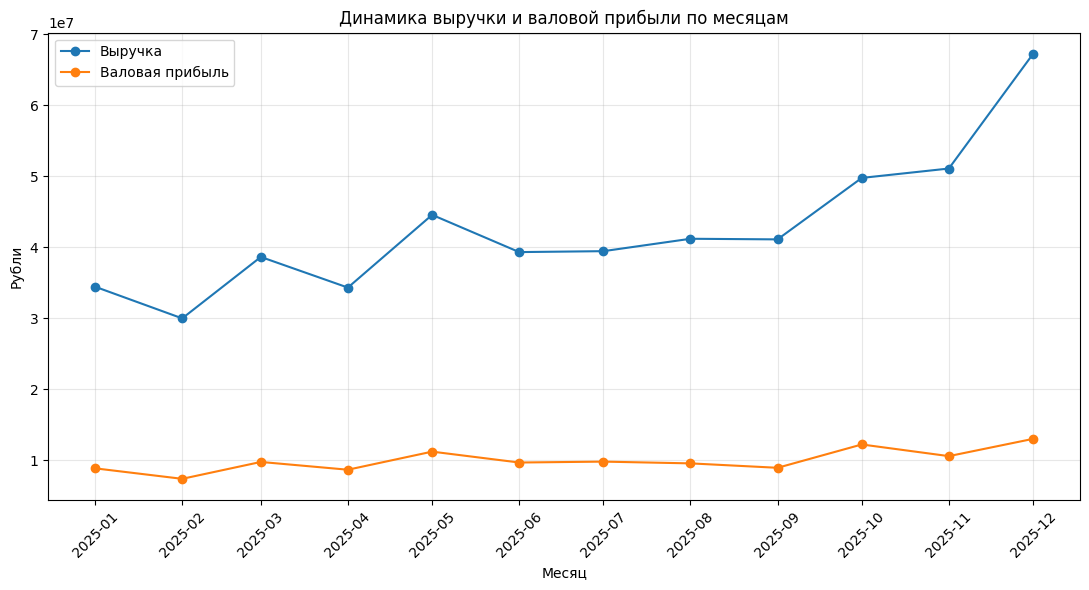

In [15]:
# Группируем данные по месяцу.
monthly = analysis_df.groupby('month_start', as_index=False).agg(
    net_revenue_rub=('net_revenue_rub','sum'),
    gross_profit_rub=('gross_profit_rub','sum'),
    orders=('order_id','nunique'),
    units=('quantity','sum'),
    return_rate=('returned','mean'),
)
# Рассчитываем средний чек по месяцу.
monthly['avg_order_value_rub'] = monthly['net_revenue_rub'] / monthly['orders']
# Выводим таблицу.
display(monthly)
# Строим динамику выручки и прибыли.
plt.figure(figsize=(11,6))
plt.plot(monthly['month_start'], monthly['net_revenue_rub'], marker='o', label='Выручка')
plt.plot(monthly['month_start'], monthly['gross_profit_rub'], marker='o', label='Валовая прибыль')
plt.title('Динамика выручки и валовой прибыли по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Рубли')
plt.legend()
plt.xticks(monthly['month_start'], [d.strftime('%Y-%m') for d in monthly['month_start']], rotation=45)
plt.grid(True, which='both', axis='both', alpha=0.3)
plt.tight_layout()
plt.savefig(CHART_DIR / '02_monthly_revenue_profit.png', dpi=150)
plt.show()

## 19. Категории, бренды, каналы и города

Сравниваем не только выручку, но и прибыль, маржинальность и возвраты. Это защищает от вывода «лидер по выручке = лучший сегмент».

,category,revenue,profit,orders,return_rate,avg_discount,margin_pct
4,Ноутбуки,"151,246,546.22","33,399,357.69",1351,0.09,0.07,0.22
6,Телевизоры,"116,466,775.51","29,882,691.66",1311,0.07,0.07,0.26
5,Смартфоны,"102,861,739.80","26,178,595.15",1567,0.07,0.07,0.25
2,Бытовая техника,"80,317,519.78","17,376,074.75",1537,0.05,0.07,0.22
1,Аудио,"29,343,880.97","5,491,566.16",1102,0.09,0.07,0.19
3,Игровая техника,"25,013,867.04","6,079,596.92",1047,0.09,0.07,0.24
0,Аксессуары,"5,570,487.93","989,324.02",1297,0.04,0.07,0.18


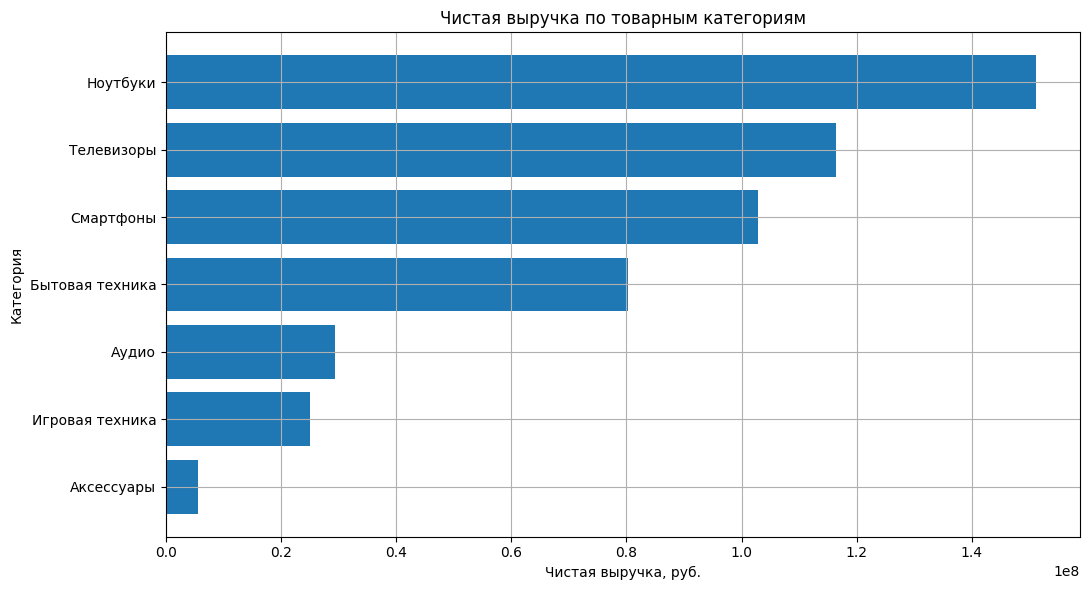

,sales_channel,revenue,profit,orders,return_rate,avg_discount,margin_pct
0,Магазин,"240,841,969.86","57,063,054.86",2842,0.06,0.06,0.24
2,Сайт,"175,162,942.09","41,032,874.16",2076,0.08,0.07,0.23
1,Маркетплейс,"94,815,905.30","21,301,277.33",1082,0.08,0.07,0.22


In [16]:
# Формируем сводку по категориям.
category_summary = analysis_df.groupby('category', as_index=False).agg(
    revenue=('net_revenue_rub','sum'),
    profit=('gross_profit_rub','sum'),
    orders=('order_id','nunique'),
    return_rate=('returned','mean'),
    avg_discount=('discount_pct','mean'),
)
# Рассчитываем маржинальность категории.
category_summary['margin_pct'] = category_summary['profit'] / category_summary['revenue']
# Сортируем по выручке.
category_summary = category_summary.sort_values('revenue', ascending=False)
# Показываем результат.
display(category_summary)
# Строим горизонтальную диаграмму выручки по категориям.
plt.figure(figsize=(11,6))
plt.barh(category_summary['category'], category_summary['revenue'])
# Инвертируем ось, чтобы лидер был сверху.
plt.gca().invert_yaxis()
plt.title('Чистая выручка по товарным категориям')
plt.xlabel('Чистая выручка, руб.')
plt.ylabel('Категория')
plt.tight_layout()
plt.savefig(CHART_DIR / '03_category_revenue.png', dpi=150)
plt.show()

# Формируем сводку по каналам.
channel_summary = analysis_df.groupby('sales_channel', as_index=False).agg(
    revenue=('net_revenue_rub','sum'),
    profit=('gross_profit_rub','sum'),
    orders=('order_id','nunique'),
    return_rate=('returned','mean'),
    avg_discount=('discount_pct','mean'),
)
# Добавляем маржинальность канала.
channel_summary['margin_pct'] = channel_summary['profit'] / channel_summary['revenue']
# Выводим каналы.
display(channel_summary.sort_values('revenue', ascending=False))

## 20. Топ товаров и брендов

Топ по выручке полезен, но далее дополняется ABC-XYZ: один рейтинг не показывает стабильность спроса.

,product_id,product_name,category,brand,revenue,profit,units,orders,return_rate
22,P023,Телевизоры Hisense Model 23,Телевизоры,Hisense,"43,267,423.20","10,349,798.31",334,282,0.06
28,P029,Бытовая техника LG Model 29,Бытовая техника,LG,"34,952,255.51","6,991,515.34",424,340,0.05
11,P012,Ноутбуки Lenovo Model 12,Ноутбуки,Lenovo,"33,806,526.54","6,197,067.75",214,178,0.08
10,P011,Ноутбуки Apple Model 11,Ноутбуки,Apple,"23,889,092.61","5,211,416.47",241,200,0.09
15,P016,Ноутбуки Apple Model 16,Ноутбуки,Apple,"22,794,368.99","3,660,072.15",225,184,0.11
1,P002,Смартфоны Samsung Model 02,Смартфоны,Samsung,"22,273,537.40","4,259,849.50",273,225,0.07
31,P032,Бытовая техника Bosch Model 32,Бытовая техника,Bosch,"20,240,514.48","5,348,570.77",372,301,0.05
18,P019,Телевизоры Samsung Model 19,Телевизоры,Samsung,"19,143,283.42","6,652,994.78",135,113,0.11
24,P025,Телевизоры LG Model 25,Телевизоры,LG,"18,642,898.55","5,522,819.16",125,104,0.07
12,P013,Ноутбуки ASUS Model 13,Ноутбуки,ASUS,"18,117,237.72","6,412,369.63",253,207,0.09


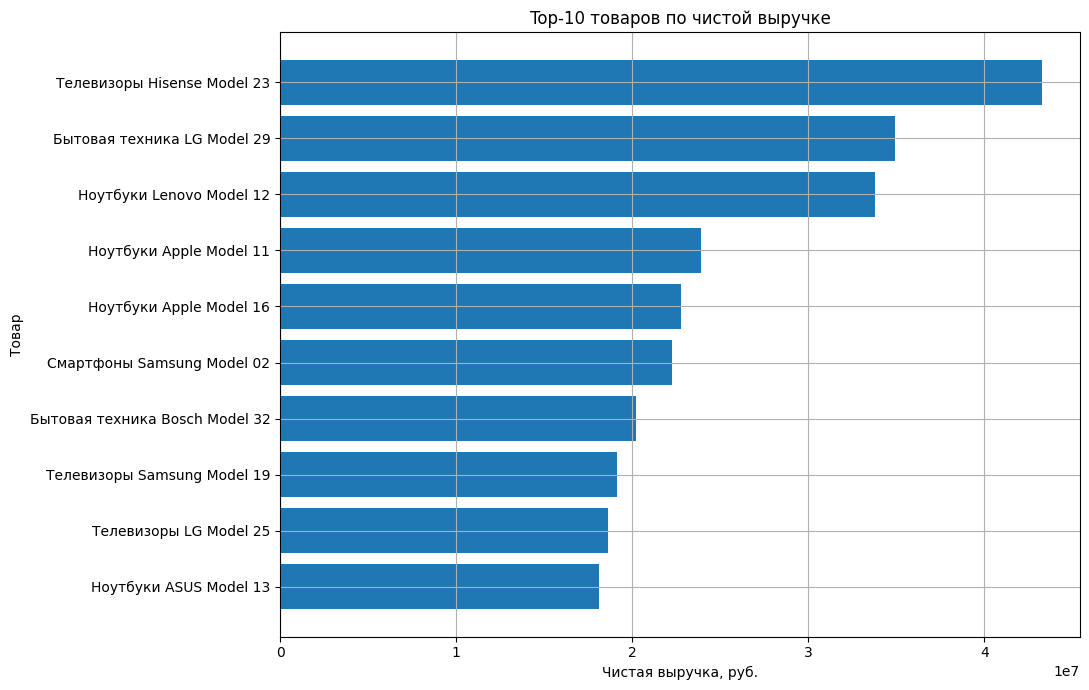

In [17]:
# Считаем показатели товара.
product_summary = analysis_df.groupby(['product_id','product_name','category','brand'], as_index=False).agg(
    revenue=('net_revenue_rub','sum'),
    profit=('gross_profit_rub','sum'),
    units=('quantity','sum'),
    orders=('order_id','nunique'),
    return_rate=('returned','mean'),
)
# Сортируем товары по выручке.
top_products = product_summary.sort_values('revenue', ascending=False).head(10)
# Показываем топ-10.
display(top_products)
# Строим график.
plt.figure(figsize=(11,7))
plt.barh(top_products['product_name'], top_products['revenue'])
# Инвертируем ось, чтобы лидер был сверху.
plt.gca().invert_yaxis()
plt.title('Top-10 товаров по чистой выручке')
plt.xlabel('Чистая выручка, руб.')
plt.ylabel('Товар')
plt.tight_layout()
plt.savefig(CHART_DIR / '04_top_products.png', dpi=150)
plt.show()

## 21. Возвраты и скидки

Возврат — риск для выручки и клиентского опыта. Скидка может стимулировать объём, но её эффект нельзя оценивать только по росту количества: важны прибыль и состав заказов.

,category,return_rate,avg_discount,revenue
3,Игровая техника,0.09,0.07,"25,013,867.04"
1,Аудио,0.09,0.07,"29,343,880.97"
4,Ноутбуки,0.09,0.07,"151,246,546.22"
5,Смартфоны,0.07,0.07,"102,861,739.80"
6,Телевизоры,0.07,0.07,"116,466,775.51"
2,Бытовая техника,0.05,0.07,"80,317,519.78"
0,Аксессуары,0.04,0.07,"5,570,487.93"


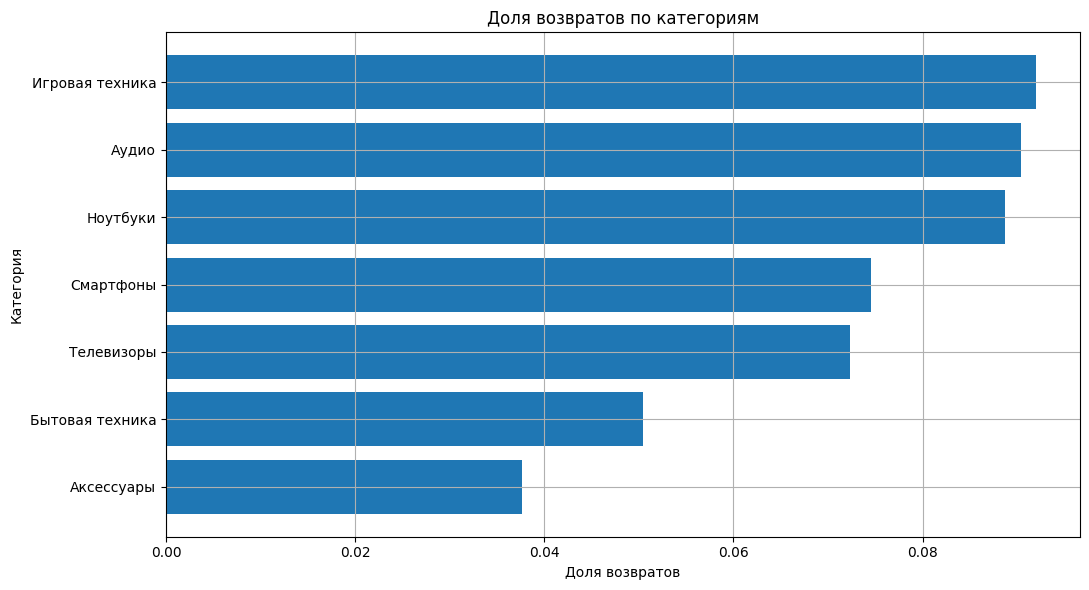

In [18]:
# Считаем возвраты и скидки по категориям.
return_discount = analysis_df.groupby('category', as_index=False).agg(
    return_rate=('returned','mean'),
    avg_discount=('discount_pct','mean'),
    revenue=('net_revenue_rub','sum'),
)
# Сортируем по возвратам.
return_discount = return_discount.sort_values('return_rate', ascending=False)
# Выводим таблицу.
display(return_discount)
# Строим график возвратов.
plt.figure(figsize=(11,6))
plt.barh(return_discount['category'], return_discount['return_rate'])
# Инвертируем ось, чтобы лидер был сверху.
plt.gca().invert_yaxis()
plt.title('Доля возвратов по категориям')
plt.xlabel('Доля возвратов')
plt.ylabel('Категория')
plt.tight_layout()
plt.savefig(CHART_DIR / '05_return_rate_category.png', dpi=150)
plt.show()

## 22. Корреляционный анализ

Используем коэффициент Спирмена для монотонных связей между числовыми признаками. Корреляция показывает связь, а не причинность.

,quantity,unit_price_rub,discount_pct,unit_cost_rub,net_revenue_rub,gross_profit_rub,returned
quantity,1.00,-0.09,0.08,-0.09,0.11,0.08,-0.01
unit_price_rub,-0.09,1.00,0.00,0.99,0.83,0.77,0.03
discount_pct,0.08,0.00,1.00,0.00,-0.02,-0.15,0.00
unit_cost_rub,-0.09,0.99,0.00,1.00,0.83,0.75,0.03
net_revenue_rub,0.11,0.83,-0.02,0.83,1.00,0.94,-0.44
gross_profit_rub,0.08,0.77,-0.15,0.75,0.94,1.00,-0.44
returned,-0.01,0.03,0.00,0.03,-0.44,-0.44,1.00


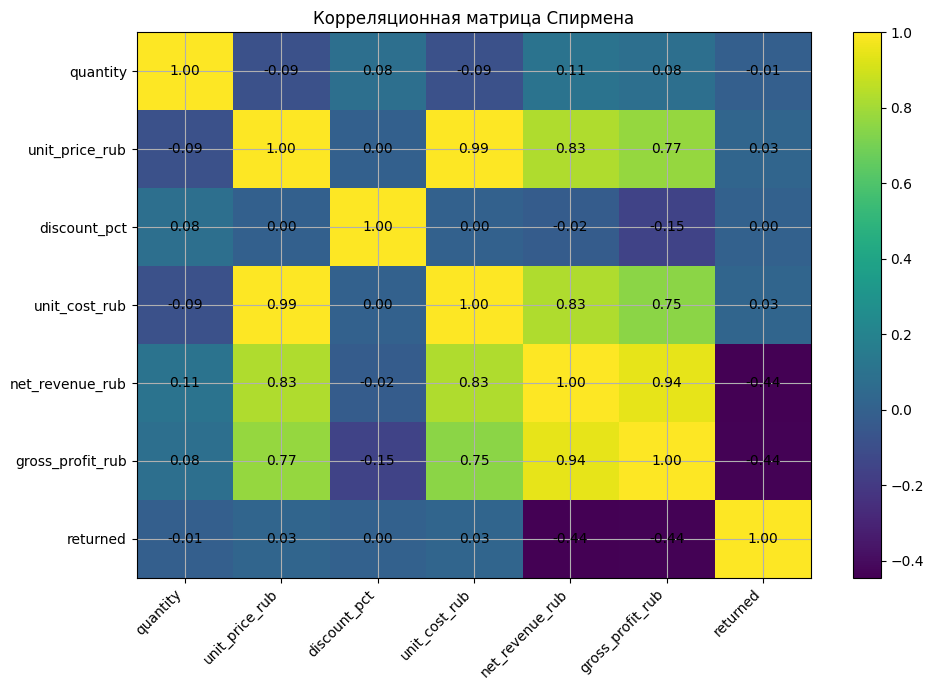

In [19]:
# Выбираем числовые признаки для корреляции.
corr_columns = ['quantity','unit_price_rub','discount_pct','unit_cost_rub','net_revenue_rub','gross_profit_rub','returned']
# Рассчитываем корреляцию Спирмена.
corr = analysis_df[corr_columns].corr(method='spearman')
# Выводим матрицу.
display(corr)
# Строим тепловую карту.
plt.figure(figsize=(10,7))
image = plt.imshow(corr.to_numpy(), aspect='auto')
# Подписываем оси названиями признаков.
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
# Добавляем значения коэффициентов в ячейки.
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
# Добавляем шкалу значений.
plt.colorbar(image)
plt.title('Корреляционная матрица Спирмена')
plt.tight_layout()
plt.savefig(CHART_DIR / '06_spearman_heatmap.png', dpi=150)
plt.show()

## 23. Статистическая проверка гипотез

Проверяем три гипотезы. Уровень значимости для учебного примера: `alpha = 0.05`.

- H1: Mann–Whitney U — сравнение распределений скидки у офлайн и онлайн строк;
- H2: χ² Пирсона — связь категории и факта возврата;
- H3: Spearman — монотонная связь скидки и количества.

In [20]:
# Фиксируем уровень значимости.
alpha = 0.05
# Формируем офлайн-выборку скидок.
offline_discount = analysis_df.loc[analysis_df['sales_channel'] == 'Магазин', 'discount_pct']
# Формируем объединённую онлайн-выборку скидок.
online_discount = analysis_df.loc[analysis_df['sales_channel'].isin(['Сайт','Маркетплейс']), 'discount_pct']
# Выполняем двусторонний тест Манна—Уитни.
h1_stat, h1_p = mannwhitneyu(online_discount, offline_discount, alternative='two-sided')
# Рассчитываем рангово-бисериальную корреляцию как размер эффекта H1.
h1_rbc = 2 * h1_stat / (len(online_discount) * len(offline_discount)) - 1
# Строим таблицу сопряжённости для категория × возврат.
contingency = pd.crosstab(analysis_df['category'], analysis_df['returned'])
# Выполняем χ² тест независимости.
h2_stat, h2_p, h2_dof, h2_expected = chi2_contingency(contingency)
# Рассчитываем размер эффекта Cramer's V для H2.
h2_n = contingency.to_numpy().sum()
h2_cramers_v = np.sqrt(h2_stat / (h2_n * min(contingency.shape[0] - 1, contingency.shape[1] - 1)))
# Выполняем корреляцию Спирмена скидки и количества.
h3_rho, h3_p = spearmanr(analysis_df['discount_pct'], analysis_df['quantity'])
# Рассчитываем средние скидки для контекста H1.
online_mean = float(online_discount.mean())
offline_mean = float(offline_discount.mean())
# Интерпретируем размер эффекта для учебного вывода.
h1_effect_label = 'малый' if abs(h1_rbc) < 0.30 else ('средний' if abs(h1_rbc) < 0.50 else 'большой')
h2_effect_label = 'малый' if h2_cramers_v < 0.10 else ('средний' if h2_cramers_v < 0.30 else 'большой')
h3_effect_label = 'очень слабый' if abs(h3_rho) < 0.10 else ('слабый' if abs(h3_rho) < 0.30 else ('умеренный' if abs(h3_rho) < 0.50 else 'сильный'))
# Собираем компактную сводку гипотез.
hypothesis_summary = pd.DataFrame([
    {'hypothesis_id':'H1','question':'Онлайн и офлайн отличаются по скидке?','method':'Mann–Whitney U','statistic':h1_stat,'p_value':h1_p,'effect_or_context':f'avg online={online_mean:.3f}; avg offline={offline_mean:.3f}; rank-biserial={h1_rbc:.3f}','effect_magnitude':h1_effect_label,'decision':'Различия статистически значимы' if h1_p < alpha else 'Недостаточно оснований для различия'},
    {'hypothesis_id':'H2','question':'Категория связана с возвратом?','method':'Chi-square','statistic':h2_stat,'p_value':h2_p,'effect_or_context':f'dof={h2_dof}; Cramers V={h2_cramers_v:.3f}','effect_magnitude':h2_effect_label,'decision':'Связь статистически значима' if h2_p < alpha else 'Недостаточно оснований для связи'},
    {'hypothesis_id':'H3','question':'Скидка связана с количеством?','method':'Spearman','statistic':h3_rho,'p_value':h3_p,'effect_or_context':f'rho={h3_rho:.3f}','effect_magnitude':h3_effect_label,'decision':'Связь статистически значима' if h3_p < alpha else 'Недостаточно оснований для связи'},
])
# Выводим сводку.
display(hypothesis_summary)

,hypothesis_id,question,method,statistic,p_value,effect_or_context,effect_magnitude,decision
0,H1,Онлайн и офлайн отличаются по скидке?,Mann–Whitney U,"13,603,289.50",0.00,avg online=0.071; avg offline=0.064; rank-bise...,малый,Различия статистически значимы
1,H2,Категория связана с возвратом?,Chi-square,55.98,0.00,dof=6; Cramers V=0.075,малый,Связь статистически значима
2,H3,Скидка связана с количеством?,Spearman,0.08,0.00,rho=0.082,очень слабый,Связь статистически значима


## 24. ABC-XYZ анализ товаров

### ABC

Товары сортируются по чистой выручке. Учебные пороги:

- A — до 80% накопленной выручки;
- B — следующие до 95%;
- C — оставшиеся.

### XYZ

Стабильность спроса оценивается по коэффициенту вариации месячного количества:

`CV = стандартное отклонение / среднее`.

Для этого синтетического кейса используются пороги **X ≤ 0,25; Y ≤ 0,50; Z > 0,50**. Это проектное учебное правило, а не универсальный стандарт.

In [21]:
# Создаём помесячную матрицу количества товара.
monthly_product_units = analysis_df.pivot_table(index='product_id', columns='month_start', values='quantity', aggfunc='sum', fill_value=0)
# Рассчитываем среднее месячное количество.
xyz_mean = monthly_product_units.mean(axis=1)
# Рассчитываем стандартное отклонение по месяцам.
xyz_std = monthly_product_units.std(axis=1, ddof=0)
# Рассчитываем коэффициент вариации.
xyz_cv = (xyz_std / xyz_mean.replace(0, np.nan)).fillna(np.inf)
# Берём базовую товарную сводку.
abc_xyz = product_summary.copy()
# Сортируем по выручке.
abc_xyz = abc_xyz.sort_values('revenue', ascending=False).reset_index(drop=True)
# Рассчитываем долю выручки.
abc_xyz['revenue_share'] = abc_xyz['revenue'] / abc_xyz['revenue'].sum()
# Рассчитываем накопленную долю.
abc_xyz['cumulative_revenue_share'] = abc_xyz['revenue_share'].cumsum()
# Присваиваем ABC-класс.
abc_xyz['abc_class'] = np.select(
    [abc_xyz['cumulative_revenue_share'] <= 0.80, abc_xyz['cumulative_revenue_share'] <= 0.95],
    ['A','B'],
    default='C'
)
# Подтягиваем CV по product_id.
abc_xyz['xyz_cv'] = abc_xyz['product_id'].map(xyz_cv)
# Присваиваем XYZ-класс.
abc_xyz['xyz_class'] = np.select(
    [abc_xyz['xyz_cv'] <= 0.25, abc_xyz['xyz_cv'] <= 0.50],
    ['X','Y'],
    default='Z'
)
# Собираем комбинированный класс.
abc_xyz['abc_xyz_class'] = abc_xyz['abc_class'] + abc_xyz['xyz_class']
# Показываем первые 15 товаров.
display(abc_xyz.head(15))
# Выводим матрицу количества товаров по классам.
abc_xyz_matrix = pd.crosstab(abc_xyz['abc_class'], abc_xyz['xyz_class'])
display(abc_xyz_matrix)

,product_id,product_name,category,brand,revenue,profit,units,orders,return_rate,revenue_share,cumulative_revenue_share,abc_class,xyz_cv,xyz_class,abc_xyz_class
0,P023,Телевизоры Hisense Model 23,Телевизоры,Hisense,"43,267,423.20","10,349,798.31",334,282,0.06,0.08,0.08,A,0.51,Z,AZ
1,P029,Бытовая техника LG Model 29,Бытовая техника,LG,"34,952,255.51","6,991,515.34",424,340,0.05,0.07,0.15,A,0.36,Y,AY
2,P012,Ноутбуки Lenovo Model 12,Ноутбуки,Lenovo,"33,806,526.54","6,197,067.75",214,178,0.08,0.07,0.22,A,0.37,Y,AY
3,P011,Ноутбуки Apple Model 11,Ноутбуки,Apple,"23,889,092.61","5,211,416.47",241,200,0.09,0.05,0.27,A,0.41,Y,AY
4,P016,Ноутбуки Apple Model 16,Ноутбуки,Apple,"22,794,368.99","3,660,072.15",225,184,0.11,0.04,0.31,A,0.39,Y,AY
5,P002,Смартфоны Samsung Model 02,Смартфоны,Samsung,"22,273,537.40","4,259,849.50",273,225,0.07,0.04,0.35,A,0.30,Y,AY
6,P032,Бытовая техника Bosch Model 32,Бытовая техника,Bosch,"20,240,514.48","5,348,570.77",372,301,0.05,0.04,0.39,A,0.44,Y,AY
7,P019,Телевизоры Samsung Model 19,Телевизоры,Samsung,"19,143,283.42","6,652,994.78",135,113,0.11,0.04,0.43,A,0.45,Y,AY
8,P025,Телевизоры LG Model 25,Телевизоры,LG,"18,642,898.55","5,522,819.16",125,104,0.07,0.04,0.47,A,0.34,Y,AY
9,P013,Ноутбуки ASUS Model 13,Ноутбуки,ASUS,"18,117,237.72","6,412,369.63",253,207,0.09,0.04,0.50,A,0.21,X,AX


xyz_class,X,Y,Z
abc_class,,,
A,1,18,2
B,4,10,0
C,2,19,4


## 25. RFM-анализ клиентов

RFM использует три признака:

- **Recency** — сколько дней прошло с последней покупки клиента до контрольной даты;
- **Frequency** — сколько уникальных заказов сделал клиент;
- **Monetary** — сколько чистой выручки принесли его покупки.

Баллы 1–5 рассчитываются квантильным разбиением. Сегменты ниже — учебная схема, а не универсальная CRM-методология.

In [22]:
# Определяем контрольную дату как день после последней даты в выборке.
snapshot_date = analysis_df['sale_date'].max() + pd.Timedelta(days=1)
# Агрегируем показатели клиента.
rfm = analysis_df.groupby('customer_id', as_index=False).agg(
    last_purchase=('sale_date','max'),
    frequency=('order_id','nunique'),
    monetary=('net_revenue_rub','sum'),
)
# Рассчитываем Recency в днях.
rfm['recency_days'] = (snapshot_date - rfm['last_purchase']).dt.days
# Для устойчивого qcut используем rank(method='first').
rfm['r_score'] = pd.qcut(rfm['recency_days'].rank(method='first'), 5, labels=[5,4,3,2,1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
# Создаём строковый RFM-код.
rfm['rfm_code'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)
# Определяем функцию учебной сегментации.
def rfm_segment(row):
    if row['r_score'] >= 4 and row['f_score'] >= 4 and row['m_score'] >= 4:
        return 'Чемпионы'
    if row['r_score'] >= 3 and row['f_score'] >= 4:
        return 'Лояльные'
    if row['m_score'] >= 4 and row['f_score'] >= 2:
        return 'Крупные покупатели'
    if row['r_score'] <= 2 and row['f_score'] >= 3:
        return 'Под риском ухода'
    if row['r_score'] >= 4 and row['f_score'] <= 2:
        return 'Новые/перспективные'
    return 'Обычные'
# Применяем сегментацию.
rfm['rfm_segment'] = rfm.apply(rfm_segment, axis=1)
# Считаем сводку по сегментам.
rfm_segment_summary = rfm.groupby('rfm_segment', as_index=False).agg(
    customers=('customer_id','nunique'),
    avg_recency=('recency_days','mean'),
    avg_frequency=('frequency','mean'),
    revenue=('monetary','sum'),
)
# Выводим сводку.
display(rfm_segment_summary.sort_values('revenue', ascending=False))

,rfm_segment,customers,avg_recency,avg_frequency,revenue
5,Чемпионы,366,17.64,7.14,"238,468,343.15"
0,Крупные покупатели,223,109.80,3.03,"90,011,596.08"
1,Лояльные,251,51.65,4.71,"84,476,680.82"
3,Обычные,696,157.43,1.41,"67,791,946.66"
4,Под риском ухода,149,174.08,2.52,"19,107,508.27"
2,Новые/перспективные,129,22.58,1.33,"10,964,742.27"


## 26. Подготовка данных для Yandex DataLens

Создаём несколько витрин с **явной гранулярностью**. Это безопаснее, чем механически соединять продажи, RFM, ABC-XYZ и статистические результаты в одну широкую таблицу.

In [23]:
# Готовим основную line-level витрину продаж.
sales_mart = analysis_df.copy()
# Сохраняем основную витрину.
sales_mart.to_csv(DATALENS_DIR / 'datalens_sales_mart.csv', index=False, encoding='utf-8-sig')
# Сохраняем месячную витрину.
monthly.to_csv(DATALENS_DIR / 'datalens_monthly_sales.csv', index=False, encoding='utf-8-sig')
# Сохраняем ABC-XYZ: одна строка = один товар.
abc_xyz.to_csv(DATALENS_DIR / 'datalens_product_abc_xyz.csv', index=False, encoding='utf-8-sig')
# Сохраняем RFM: одна строка = один клиент.
rfm.to_csv(DATALENS_DIR / 'datalens_customer_rfm.csv', index=False, encoding='utf-8-sig')
# Формируем сводку категория × канал.
category_channel = analysis_df.groupby(['category','sales_channel'], as_index=False).agg(
    revenue=('net_revenue_rub','sum'),
    profit=('gross_profit_rub','sum'),
    orders=('order_id','nunique'),
    units=('quantity','sum'),
    return_rate=('returned','mean'),
    avg_discount=('discount_pct','mean'),
)
# Рассчитываем маржинальность в сводке.
category_channel['margin_pct'] = category_channel['profit'] / category_channel['revenue']
# Сохраняем сводку.
category_channel.to_csv(DATALENS_DIR / 'datalens_category_channel.csv', index=False, encoding='utf-8-sig')
# Сохраняем статистические результаты.
hypothesis_summary.to_csv(DATALENS_DIR / 'datalens_hypothesis_summary.csv', index=False, encoding='utf-8-sig')
# Готовим одно-строчную контрольную KPI-витрину.
kpi_export = pd.DataFrame([{
    'clean_rows': len(analysis_df),
    'unique_orders': total_orders,
    'unique_customers': int(analysis_df['customer_id'].nunique()),
    'net_revenue_rub': round(total_revenue,2),
    'gross_profit_rub': round(total_profit,2),
    'avg_order_value_rub': round(avg_order_value,2),
    'overall_margin_pct': round(overall_margin,6),
    'return_rate': round(return_rate,6),
    'avg_discount': round(avg_discount,6),
    'units_sold': units_sold,
}])
# Сохраняем KPI.
kpi_export.to_csv(DATALENS_DIR / 'datalens_kpi.csv', index=False, encoding='utf-8-sig')
# Выводим список созданных файлов.
for path in sorted(DATALENS_DIR.glob('*.csv')):
    print(path.name, '—', f'{path.stat().st_size/1024:.1f} KB')

datalens_category_channel.csv — 2.7 KB
datalens_customer_rfm.csv — 116.0 KB
datalens_hypothesis_summary.csv — 0.7 KB
datalens_kpi.csv — 0.2 KB
datalens_monthly_sales.csv — 1.0 KB
datalens_product_abc_xyz.csv — 11.0 KB
datalens_sales_mart.csv — 2896.8 KB


## 27. Рекомендуемая структура дашборда DataLens

Основная вкладка строится на `datalens_sales_mart.csv`: KPI, месячная динамика, категории, каналы, города, товары и возвраты.

Отдельные вкладки используют `datalens_product_abc_xyz.csv`, `datalens_customer_rfm.csv` и `datalens_hypothesis_summary.csv`.

**Важно:** эти предрассчитанные таблицы не пересчитываются автоматически от селекторов основной line-level витрины. Подробная схема находится в `DATALENS_DASHBOARD_GUIDE.md`.

## 28. Выводы, ограничения и рекомендации

Финальный текст ниже формируется из выполненных расчётов. Мы разделяем измеренные факты, интерпретацию и рекомендации.

In [24]:
# Находим лидирующую категорию по выручке.
top_category = category_summary.iloc[0]
# Находим канал с максимальной выручкой.
top_channel = channel_summary.sort_values('revenue', ascending=False).iloc[0]
# Находим категорию с максимальной долей возвратов.
top_return_category = return_discount.iloc[0]
# Определяем наиболее распространённый ABC-XYZ класс.
most_common_abc_xyz = abc_xyz['abc_xyz_class'].value_counts().idxmax()
# Определяем крупнейший RFM-сегмент по выручке.
top_rfm_segment = rfm_segment_summary.sort_values('revenue', ascending=False).iloc[0]
# Формируем итоговый текст.
final_text = f'''### Итоговые наблюдения по синтетическим данным

- После очистки анализируется **{len(analysis_df):,} уникальных строк продаж** и **{total_orders:,} заказов**.
- Чистая выручка учебной выборки: **{total_revenue:,.0f} руб.**, валовая прибыль: **{total_profit:,.0f} руб.**
- Средний чек: **{avg_order_value:,.0f} руб.**, общая маржинальность: **{overall_margin:.1%}**.
- Лидер по выручке среди категорий: **{top_category['category']}**.
- Лидер по выручке среди каналов: **{top_channel['sales_channel']}**.
- Наибольшая доля возвратов в выборке наблюдается у категории **{top_return_category['category']}** ({top_return_category['return_rate']:.1%}).
- Наиболее частый комбинированный ABC-XYZ класс: **{most_common_abc_xyz}**.
- Наибольшую выручку среди RFM-сегментов формирует сегмент **{top_rfm_segment['rfm_segment']}**.

### Статистические проверки

- H1: p-value = **{h1_p:.3g}**, rank-biserial = **{h1_rbc:.3f}** ({h1_effect_label} эффект). Онлайн- и офлайн-скидки {'различаются статистически значимо' if h1_p < alpha else 'не показали статистически значимого различия'}; практическая величина различия невелика.
- H2: p-value = **{h2_p:.3g}**, Cramer's V = **{h2_cramers_v:.3f}** ({h2_effect_label} эффект). Категория и возврат {'связаны статистически значимо' if h2_p < alpha else 'не показали статистически значимой связи'}; связь по величине эффекта слабая.
- H3: rho = **{h3_rho:.3f}** ({h3_effect_label} связь), p-value = **{h3_p:.3g}**. Связь скидки и количества {'статистически значима' if h3_p < alpha else 'не подтверждена на выбранном уровне значимости'}, но по силе она очень мала.

### Ограничения

- Данные полностью синтетические.
- Возвраты и себестоимость смоделированы упрощённо.
- Не учитываются комиссии маркетплейсов, логистика, налоги и операционные расходы.
- ABC-XYZ и RFM используют учебные пороги и правила.
- Наблюдаемые статистические связи не являются доказательством причинности.

### Практические рекомендации

- использовать вкладку обзора для совместного контроля выручки, прибыли, маржи и возвратов;
- отдельно анализировать товары классов AX/AY и товары CZ как разные управленческие задачи;
- использовать RFM для постановки маркетинговых гипотез, а не как готовую автоматическую стратегию;
- при переносе в реальный бизнес согласовать определения KPI, возвратов, прибыли, ABC-XYZ и RFM с владельцами процессов;
- не ожидать автоматического пересчёта предрассчитанных статистических/RFM/ABC-XYZ таблиц от селекторов DataLens.
'''
# Показываем итоговый текст в notebook.
display(Markdown(final_text))
# Сохраняем итоговую сводку в отдельный Markdown-файл.
(PROJECT_DIR / 'RESULTS_SUMMARY.md').write_text('# Результаты анализа\n\n' + final_text, encoding='utf-8')

### Итоговые наблюдения по синтетическим данным

- После очистки анализируется **9,975 уникальных строк продаж** и **6,000 заказов**.
- Чистая выручка учебной выборки: **510,820,817 руб.**, валовая прибыль: **119,397,206 руб.**
- Средний чек: **85,137 руб.**, общая маржинальность: **23.4%**.
- Лидер по выручке среди категорий: **Ноутбуки**.
- Лидер по выручке среди каналов: **Магазин**.
- Наибольшая доля возвратов в выборке наблюдается у категории **Игровая техника** (9.2%).
- Наиболее частый комбинированный ABC-XYZ класс: **CY**.
- Наибольшую выручку среди RFM-сегментов формирует сегмент **Чемпионы**.

### Статистические проверки

- H1: p-value = **8.61e-17**, rank-biserial = **0.096** (малый эффект). Онлайн- и офлайн-скидки различаются статистически значимо; практическая величина различия невелика.
- H2: p-value = **2.94e-10**, Cramer's V = **0.075** (малый эффект). Категория и возврат связаны статистически значимо; связь по величине эффекта слабая.
- H3: rho = **0.082** (очень слабый связь), p-value = **2.05e-16**. Связь скидки и количества статистически значима, но по силе она очень мала.

### Ограничения

- Данные полностью синтетические.
- Возвраты и себестоимость смоделированы упрощённо.
- Не учитываются комиссии маркетплейсов, логистика, налоги и операционные расходы.
- ABC-XYZ и RFM используют учебные пороги и правила.
- Наблюдаемые статистические связи не являются доказательством причинности.

### Практические рекомендации

- использовать вкладку обзора для совместного контроля выручки, прибыли, маржи и возвратов;
- отдельно анализировать товары классов AX/AY и товары CZ как разные управленческие задачи;
- использовать RFM для постановки маркетинговых гипотез, а не как готовую автоматическую стратегию;
- при переносе в реальный бизнес согласовать определения KPI, возвратов, прибыли, ABC-XYZ и RFM с владельцами процессов;
- не ожидать автоматического пересчёта предрассчитанных статистических/RFM/ABC-XYZ таблиц от селекторов DataLens.


1999

### Финальный QA

Перед завершением проверяем существование ключевых файлов и согласованность основных размеров.

In [25]:
# Проверяем, что очищенный файл записан.
assert CLEAN_PATH.exists(), 'Не создан очищенный CSV.'
# Проверяем, что создано семь BI-витрин.
assert len(list(DATALENS_DIR.glob('*.csv'))) == 7, 'Ожидалось семь DataLens CSV-файлов.'
# Проверяем ограничение исходных 10 000 строк.
assert len(raw_df) == 10000, 'Нарушено ограничение исходного датасета.'
# Проверяем ожидаемый эффект 25 полных дублей.
assert len(analysis_df) == 9975, 'После удаления 25 полных дублей ожидается 9 975 строк.'
# Проверяем наличие итоговой сводки.
assert (PROJECT_DIR / 'RESULTS_SUMMARY.md').exists(), 'Не создан RESULTS_SUMMARY.md.'
# Печатаем итоговый статус.
print('FINAL QA: ключевые файлы созданы, notebook завершён без ошибок.')

FINAL QA: ключевые файлы созданы, notebook завершён без ошибок.


### Источники по инструментам и методам

- pandas: https://pandas.pydata.org/docs/
- SciPy statistics: https://docs.scipy.org/doc/scipy/reference/stats.html
- Yandex DataLens — подключение к файлу: https://yandex.cloud/ru/docs/datalens/operations/connection/create-file
- Yandex DataLens — вычисляемые поля: https://yandex.cloud/ru/docs/datalens/concepts/calculations/
- Yandex DataLens — селекторы: https://yandex.cloud/ru/docs/datalens/dashboard/selector
- Yandex DataLens — связи виджетов: https://yandex.cloud/ru/docs/datalens/dashboard/link

Пороговые правила ABC-XYZ и схема RFM в этом notebook являются учебными проектными решениями, а не универсальными отраслевыми стандартами.